In [1]:
import pandas as pd
import pymssql
import matplotlib.pyplot as plt

DB_info = {'server':'192.168.61.119:7622','user':'BAReporting', 'password':'KeHeCReme8he'}

In [53]:
sql = """
DECLARE @start_date date = '2026-08-01';
DECLARE @end_date date = '2026-09-01';

WITH order_base AS (
    SELECT
        DATEDIFF(SECOND, tao.CreateTime, tao.AcceptedTime) / 60.0
            AS accept_order_time_minutes
    FROM mars.dbo.TakeAwayOrder tao WITH (NOLOCK)
    INNER JOIN openrice3.dbo.Poi poi WITH (NOLOCK)
        ON poi.PoiId = tao.ORPoiId
    WHERE tao.AcceptedTime >= @start_date
      AND tao.AcceptedTime < @end_date
      AND tao.Status = 10
      AND tao.AcceptedTime >= tao.CreateTime
      AND DATEPART(HOUR, tao.AcceptedTime) BETWEEN 12 AND 14
      AND poi.DistrictId IN (1004, 1009, 1014, 1018, 1023)
      AND JSON_VALUE(tao.MetaData, '$.AcceptedUser.Type') IS NOT NULL
      AND JSON_VALUE(tao.MetaData, '$.AcceptedUser.Type') <> '0'
      AND DATEDIFF(MINUTE, tao.CreateTime, tao.AcceptedTime) <= 30
),
time_distribution AS (
    SELECT
        FLOOR(accept_order_time_minutes * 2) / 2.0 AS bucket_start_minutes
    FROM order_base
)
SELECT
    CAST(bucket_start_minutes AS decimal(10, 1)) AS accept_order_time_from_minutes,
    CAST(bucket_start_minutes + 0.5 AS decimal(10, 1)) AS accept_order_time_to_minutes,
    COUNT_BIG(*) AS takeaway_order_count
FROM time_distribution
GROUP BY bucket_start_minutes
ORDER BY bucket_start_minutes;
"""

with pymssql.connect(
    DB_info["server"],
    DB_info["user"],
    DB_info["password"],
    "mars",
) as conn:
    df = pd.read_sql(sql, conn)

C:\Users\lenalee\AppData\Local\Temp\ipykernel_41896\3508401989.py:42: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


In [54]:
df

,accept_order_time_from_minutes,accept_order_time_to_minutes,takeaway_order_count
0,0.0,0.5,3573
1,0.5,1.0,1894
2,1.0,1.5,589
3,1.5,2.0,206
4,2.0,2.5,150
5,2.5,3.0,144
6,3.0,3.5,130
7,3.5,4.0,114
8,4.0,4.5,60
9,4.5,5.0,35


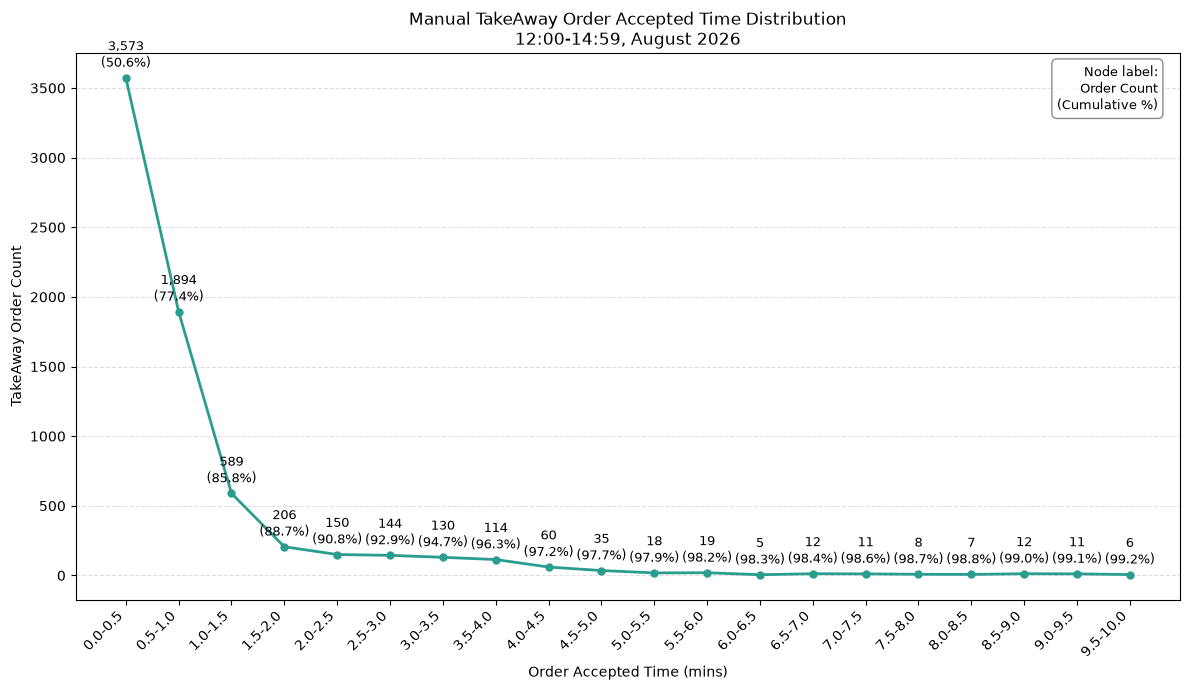

In [55]:
total_order_count = df["takeaway_order_count"].sum()

plot_df = df[
    (df["accept_order_time_from_minutes"] >= 0)
    & (df["accept_order_time_to_minutes"] <= 10)
].copy()

plot_df["accept_time_midpoint"] = (
    plot_df["accept_order_time_from_minutes"]
    + plot_df["accept_order_time_to_minutes"]
) / 2

plot_df["accept_time_range"] = (
    plot_df["accept_order_time_from_minutes"].map("{:.1f}".format)
    + "-"
    + plot_df["accept_order_time_to_minutes"].map("{:.1f}".format)
)

plot_df["cumulative_order_count"] = plot_df["takeaway_order_count"].cumsum()
plot_df["cumulative_percentage"] = (
    plot_df["cumulative_order_count"] / total_order_count * 100
)

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(
    plot_df["accept_time_midpoint"],
    plot_df["takeaway_order_count"],
    marker="o",
    linewidth=2,
    markersize=5,
    color="#2A9D8F",
)

for _, row in plot_df.iterrows():
    ax.annotate(
        (
            f'{row["takeaway_order_count"]:,}\n'
            f'({row["cumulative_percentage"]:.1f}%)'
        ),
        (row["accept_time_midpoint"], row["takeaway_order_count"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9,
    )

ax.set_xlabel("Order Accepted Time (mins)")
ax.set_ylabel("TakeAway Order Count")
ax.set_title(
    "Manual TakeAway Order Accepted Time Distribution\n"
    "12:00-14:59, August 2026"
)
ax.text(
    0.98,
    0.98,
    "Node label:\nOrder Count\n(Cumulative %)",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9,
    bbox={
        "boxstyle": "round,pad=0.4",
        "facecolor": "white",
        "edgecolor": "#808080",
        "alpha": 0.9,
    },
)
ax.set_xticks(plot_df["accept_time_midpoint"])
ax.set_xticklabels(plot_df["accept_time_range"], rotation=45, ha="right")

ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [58]:
df["cumulative_order_count"] = df["takeaway_order_count"].cumsum()
df["cumulative_order_%"] = (
    df["cumulative_order_count"] / total_order_count * 100
).map("{:.2f}".format)

# remove df["cumulative_order_count"]
df.drop(columns=["cumulative_order_count"], inplace=True)
#df.drop(columns=["cumulative_percentage"], inplace=True)

df

df.to_excel("TA_AcceptTime_Distribution.xlsx", index=False)

In [29]:
sql = """
DECLARE @start_date date = '2026-08-01';
DECLARE @end_date date = '2026-09-01';

WITH order_base AS (
    SELECT
        DATEPART(HOUR, tao.AcceptedTime) AS accepted_hour,
        FLOOR(
            DATEDIFF(SECOND, tao.CreateTime, tao.AcceptedTime) / 60.0 * 2
        ) / 2.0 AS bucket_start_minutes
    FROM mars.dbo.TakeAwayOrder tao WITH (NOLOCK)
    INNER JOIN openrice3.dbo.Poi poi WITH (NOLOCK)
        ON poi.PoiId = tao.ORPoiId
    WHERE tao.AcceptedTime >= @start_date
      AND tao.AcceptedTime < @end_date
      AND tao.Status = 10
      AND tao.AcceptedTime >= tao.CreateTime
      AND DATEPART(HOUR, tao.AcceptedTime) BETWEEN 12 AND 14
      AND poi.DistrictId IN (1004, 1009, 1014, 1018, 1023)
      AND JSON_VALUE(tao.MetaData, '$.AcceptedUser.Type') IS NOT NULL
      AND JSON_VALUE(tao.MetaData, '$.AcceptedUser.Type') <> '0'
      AND DATEDIFF(MINUTE, tao.CreateTime, tao.AcceptedTime) <= 30
)
SELECT
    CASE
        WHEN GROUPING(accepted_hour) = 1 THEN 'Total (12:00-14:59)'
        ELSE CONCAT(RIGHT(CONCAT('0', accepted_hour), 2), ':00-',
                    RIGHT(CONCAT('0', accepted_hour), 2), ':59')
    END AS time_period,
    CAST(bucket_start_minutes AS decimal(10, 1)) AS accept_order_time_from_minutes,
    CAST(bucket_start_minutes + 0.5 AS decimal(10, 1)) AS accept_order_time_to_minutes,
    COUNT_BIG(*) AS takeaway_order_count
FROM order_base
GROUP BY GROUPING SETS (
    (accepted_hour, bucket_start_minutes),
    (bucket_start_minutes)
)
ORDER BY
    CASE WHEN GROUPING(accepted_hour) = 1 THEN 99 ELSE accepted_hour END,
    bucket_start_minutes;
"""

with pymssql.connect(
    DB_info["server"],
    DB_info["user"],
    DB_info["password"],
    "mars",
) as conn:
    df_1 = pd.read_sql(sql, conn)

C:\Users\lenalee\AppData\Local\Temp\ipykernel_41896\738158989.py:49: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_1 = pd.read_sql(sql, conn)


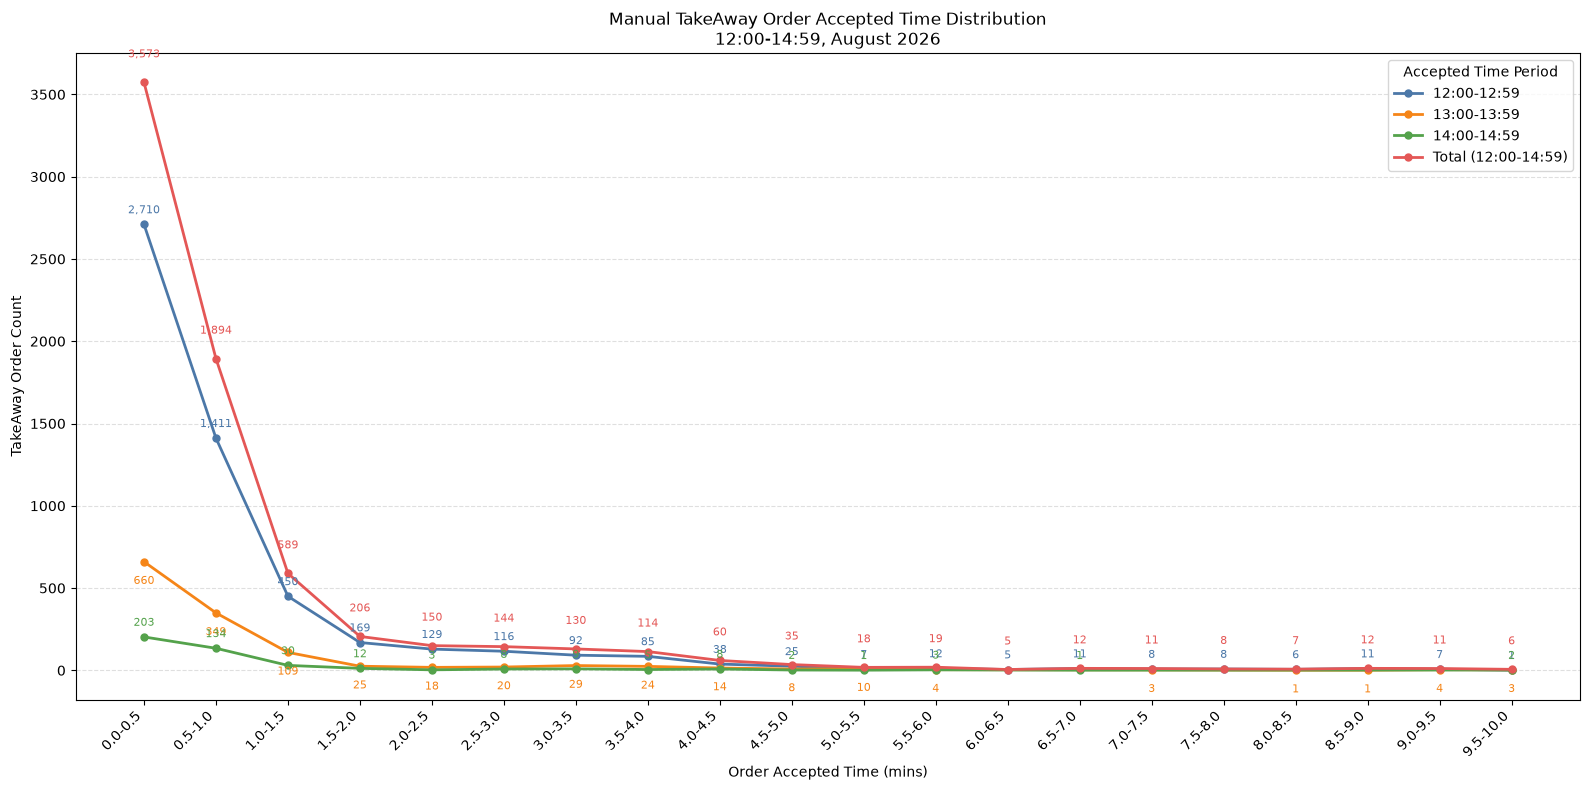

In [40]:
plot_df = df_1[
    (df_1["accept_order_time_from_minutes"] >= 0)
    & (df_1["accept_order_time_to_minutes"] <= 10)
].copy()

plot_df["accept_time_midpoint"] = (
    plot_df["accept_order_time_from_minutes"]
    + plot_df["accept_order_time_to_minutes"]
) / 2

plot_df["accept_time_range"] = (
    plot_df["accept_order_time_from_minutes"].map("{:.1f}".format)
    + "-"
    + plot_df["accept_order_time_to_minutes"].map("{:.1f}".format)
)

series_order = [
    "12:00-12:59",
    "13:00-13:59",
    "14:00-14:59",
    "Total (12:00-14:59)",
]

series_style = {
    "12:00-12:59": {"color": "#4C78A8", "offset": 8},
    "13:00-13:59": {"color": "#F58518", "offset": -16},
    "14:00-14:59": {"color": "#54A24B", "offset": 8},
    "Total (12:00-14:59)": {"color": "#E45756", "offset": 18},
}

fig, ax = plt.subplots(figsize=(16, 8))

for period in series_order:
    period_df = plot_df[plot_df["time_period"] == period]

    ax.plot(
        period_df["accept_time_midpoint"],
        period_df["takeaway_order_count"],
        marker="o",
        linewidth=2,
        markersize=5,
        label=period,
        color=series_style[period]["color"],
    )

    for _, row in period_df.iterrows():
        ax.annotate(
            f'{row["takeaway_order_count"]:,}',
            (row["accept_time_midpoint"], row["takeaway_order_count"]),
            xytext=(0, series_style[period]["offset"]),
            textcoords="offset points",
            ha="center",
            fontsize=8,
            color=series_style[period]["color"],
        )

ax.set_xlabel("Order Accepted Time (mins)")
ax.set_ylabel("TakeAway Order Count")
ax.set_title(
    "Manual TakeAway Order Accepted Time Distribution\n"
    "12:00-14:59, August 2026"
)

reference_df = plot_df[plot_df["time_period"] == "Total (12:00-14:59)"]
ax.set_xticks(reference_df["accept_time_midpoint"])
ax.set_xticklabels(reference_df["accept_time_range"], rotation=45, ha="right")

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(title="Accepted Time Period")
plt.tight_layout()
plt.show()